
# Guia Completo: Knowledge Distillation de Classificadores de Imagens

**MO434 - Aprendizado Profundo para Visao Computacional**

---

## Objetivo do Projeto

Treinar um modelo **student** leve que imita as representacoes internas de um modelo **teacher**
pre-treinado (VGG, ResNet, ConvNeXt), de forma que o student consiga classificar imagens com
muito menos parametros e operacoes (GFLOPs) do que o teacher.

## As 3 Fases

```
Fase 1 -> Treinar o CLASSIFICADOR do teacher (encoder congelado)
Fase 2 -> Treinar ENCODER + PREDITOR do student (imitacao de features do teacher)
Fase 3 -> Testar student com o MESMO classificador treinado na Fase 1
```

## As 5 Perguntas de Pesquisa

| # | Pergunta | O que implementar |
|---|----------|------------------|
| Q1 | Qual teacher transfere melhor? | Comparar VGG-16, ResNet-50, ConvNeXt-S |
| Q2 | Student deve prever pre-GAP ou post-GAP? | Duas variantes de preditor |
| Q3 | Qual a melhor arquitetura do student? | Plain CNN vs Depthwise vs Mini-ResNet |
| Q4 | Qual a melhor funcao de perda? | Ablacao de alpha em L = alpha*MSE + (1-alpha)*CE |
| Q5 | O que aprender da literatura de KD? | Implementar RKD e comparar com baseline |

---

## Datasets Utilizados

| Dataset | Classes | Imagens | Tamanho | Papel no projeto |
|---------|---------|---------|---------|-----------------|
| **Flowers-102** | 102 | ~8K | ~330MB | **Principal (Q1-Q4)**: fine-grained, 102 classes exige representacoes ricas |
| **Oxford-IIIT-Pet** | 37 | ~7K | ~800MB | **Validacao cruzada**: confirma que resultados generalizam |

**Por que Flowers-102 para Q1?** Com 102 classes de flores visualmente similares,
o teacher precisa de representacoes discriminativas de alta qualidade. A diferenca
entre VGG, ResNet e ConvNeXt fica mais evidente do que em datasets com classes
bem separadas.

**Por que Oxford-IIIT-Pet como segundo dataset?** 37 racas de caes e gatos e
um problema diferente (granularidade fina, menos classes), confirmando que
os resultados do student nao dependem de um unico dominio.


---
## Secao 0 - Instalacao e Importacoes

Execute esta celula uma vez para instalar as dependencias.


In [19]:
# instalacao das dependencias do projeto
# descomente conforme necessario

# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
# !pip install fvcore torchmetrics matplotlib seaborn pandas tqdm


In [20]:

# importacoes gerais do projeto
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from copy import deepcopy
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, datasets, models

# classes
from kd_utils import (
    ImageTransforms, DatasetManager,
    TeacherWrapper,
    PlainCNNEncoder, DepthwiseCNNEncoder, MiniResNetEncoder,
    PreditorPostGAP, PreditorPreGAP, StudentModel,
    PerdaKD, PerdaRKD,
    Trainer, Evaluator,
    plotar_curvas, plotar_comparacao_mse_rkd, plotar_graficos_analise,
)

# verificacao de dispositivo (gpu ou cpu)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"dispositivo em uso: {device}")
if torch.cuda.is_available():
    print(f"gpu: {torch.cuda.get_device_name(0)}")
    print(f"memoria gpu: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


dispositivo em uso: cuda
gpu: Tesla T4
memoria gpu: 15.6 GB


---
## Secao 1 - Preparacao dos Datasets

### Por que usar 2 datasets?

O enunciado exige multiplos datasets para garantir que os resultados sejam
**generalizaveis** e nao especificos de um unico dominio.

### Pre-processamento para modelos pre-treinados no ImageNet

Todos os backbones (VGG, ResNet, ConvNeXt) foram treinados com imagens normalizadas
com a **media e desvio padrao do ImageNet**. E obrigatorio usar os mesmos valores:

```
media  = [0.485, 0.456, 0.406]
desvio = [0.229, 0.224, 0.225]
```

Alem disso, os modelos esperam entradas de **224x224 pixels**.


In [21]:

# parametros de normalizacao do imagenet (obrigatorio para modelos pre-treinados)
# todos os valores estao encapsulados em ImageTransforms (kd_utils.py)
IMAGENET_MEAN = ImageTransforms.IMAGENET_MEAN
IMAGENET_STD  = ImageTransforms.IMAGENET_STD

# transformacoes padrao (validacao e teste, sem augmentacao)
transform_val = ImageTransforms.get_val_transform()

# transformacoes com augmentacao (somente para o conjunto de treino)
# a augmentacao aumenta a diversidade sem coletar novos dados
transform_train = ImageTransforms.get_train_transform()

print("transformacoes definidas com sucesso!")


transformacoes definidas com sucesso!


In [22]:

# ── carregamento dos datasets ─────────────────────────────────────────────────
# DatasetManager cuida do download, splits e DataLoaders (kd_utils.py)

# dataset 1: flowers-102 - 102 classes de flores, ~8.000 imagens
# splits oficiais: train (1020 imgs), val (1020 imgs), test (6149 imgs)
# ideal para comparar teachers (Q1): fine-grained, ConvNeXt tende a se sair melhor

# dataset 2: oxford-iiit-pet - 37 classes (racas de caes e gatos), ~7.000 imagens
# testa transferencia em classificacao de granularidade fina com menos dados

dataset_manager = DatasetManager(data_root='./data', batch_size=32, num_workers=2)
DATASETS = dataset_manager.load_all()

# aliases para acesso direto aos loaders (compatibilidade com o resto do notebook)
loader_f102_train = DATASETS['flowers102']['train']
loader_f102_val   = DATASETS['flowers102']['val']
loader_f102_test  = DATASETS['flowers102']['test']

loader_pets_train = DATASETS['pets']['train']
loader_pets_val   = DATASETS['pets']['val']
loader_pets_test  = DATASETS['pets']['test']


flowers-102 -> treino: 1,020 | val: 1,020 | teste: 6,149
oxford-pets -> treino: 2,944 | val: 736 | teste: 3,669


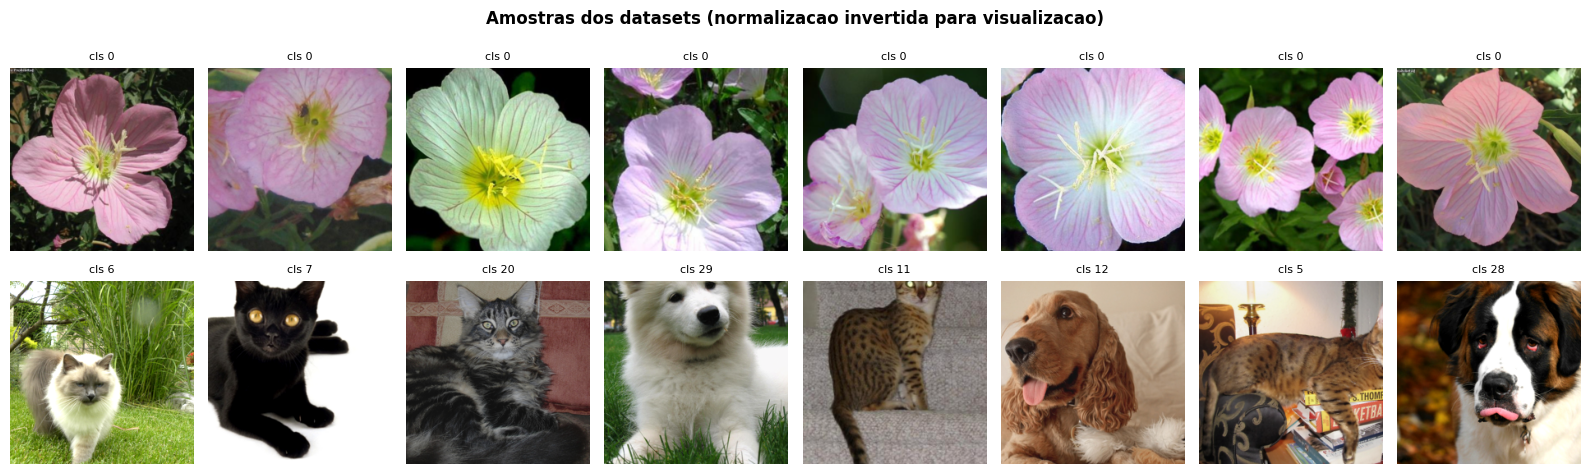

In [23]:

# visualizacao: amostras de imagens dos dois datasets
# dataset_manager.visualizar_amostras inverte a normalizacao do ImageNet
# para exibir as imagens corretamente
dataset_manager.visualizar_amostras(n_imgs=8)


---
## Secao 2 - Modelo Teacher

### Conceito: O papel do Teacher no KD

O **teacher** e um backbone pre-treinado no ImageNet cujo encoder esta **congelado**
(pesos nunca atualizados). Apenas o classificador final e treinado no novo dataset.

### Estrutura de um backbone moderno

```
Imagem [B, 3, 224, 224]
    |
[ENCODER CONGELADO]   <- pesos ImageNet, nunca atualizados
    |
Feature map pre-GAP: [B, C, 7, 7]
    |
Global Average Pooling (GAP)
    |
Vetor post-GAP: [B, C]
    |
[CLASSIFICADOR TREINAVEL]   <- so esta parte e treinada na Fase 1
    |
Logits: [B, n_classes]
```

### Teachers comparados no projeto

| Teacher | Parametros | GFLOPs | dim post-GAP | Caracteristica |
|---------|------------|--------|--------------|----------------|
| VGG-16 | 138M | 15.5 | 512 | Classico, sem skip connections |
| ResNet-50 | 25M | 4.1 | 2048 | Baseline mais estudado em KD |
| ConvNeXt-Small | 50M | 8.7 | 768 | Moderno, melhor accuracy |


In [24]:

# TeacherWrapper definido em kd_utils.py
# encapsula encoder + gap + classificador de forma modular
# permite extrair pre-gap [B, C, 7, 7] e post-gap [B, C] de forma uniforme

# teste rapido de shapes para cada teacher
print("verificando shapes dos teachers...")
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224)
    for name in ['vgg16', 'resnet50', 'convnext_small']:
        t      = TeacherWrapper(name, n_classes=100)
        t.eval()
        pre    = t.get_pre_gap(dummy)
        post   = t.get_post_gap(dummy)
        logits = t(dummy)
        params = sum(p.numel() for p in t.parameters()) / 1e6
        print(f"  {name:16s} | pre-gap: {str(pre.shape):22s} | post-gap: {str(post.shape):14s} | params: {params:.1f}M")


verificando shapes dos teachers...
  vgg16            | pre-gap: torch.Size([2, 512, 7, 7]) | post-gap: torch.Size([2, 512]) | params: 14.8M
  resnet50         | pre-gap: torch.Size([2, 2048, 7, 7]) | post-gap: torch.Size([2, 2048]) | params: 23.7M
  convnext_small   | pre-gap: torch.Size([2, 768, 7, 7]) | post-gap: torch.Size([2, 768]) | params: 49.5M


---
## Secao 3 - Fase 1: Treinar o Classificador do Teacher

### O que fazemos aqui?

O encoder do teacher ja sabe extrair features (pre-treinado no ImageNet).
Mas o classificador original foi treinado para 1000 classes do ImageNet, nao
para as classes do nosso dataset.

Na Fase 1:
1. Congelamos o encoder (nenhum gradiente passa por ele)
2. Trocamos a ultima camada do classificador por uma nova com `n_classes` saidas
3. Treinamos **apenas o classificador** com Cross-Entropy Loss

### Por que isso e critico para o KD?

O classificador treinado na Fase 1 e **reutilizado exatamente** na Fase 3 para
avaliar o student. Isso forca o student a produzir features que estejam
**no mesmo espaco** do teacher.

### Funcao de perda: Cross-Entropy

$$L_{CE} = -\frac{1}{N}\sum_{i=1}^{N} \log(\hat{y}_{i, c_i})$$

onde $\hat{y}_{i, c_i}$ e a probabilidade predita para a classe correta $c_i$.


In [25]:

# inicializa o Trainer e o Evaluator
# todos os loops de treino (fase 1 e fase 2) estao encapsulados em Trainer (kd_utils.py)
# a avaliacao final (fase 3) e as metricas de eficiencia estao em Evaluator (kd_utils.py)
trainer   = Trainer(device=device)
evaluator = Evaluator(device=device)

print("trainer e evaluator inicializados.")


trainer e evaluator inicializados.



 teacher: RESNET50 | dataset: flowers102
encoder resnet50 congelado.
  parametros treinaveis: 208,998


  epoca   1 | loss_tr=4.3595 acc_tr=0.137 | loss_vl=3.7673 acc_vl=0.573


  epoca   5 | loss_tr=1.5072 acc_tr=0.969 | loss_vl=1.8949 acc_vl=0.847


  epoca  10 | loss_tr=0.8208 acc_tr=0.987 | loss_vl=1.3907 acc_vl=0.869


  epoca  15 | loss_tr=0.6842 acc_tr=0.992 | loss_vl=1.3111 acc_vl=0.863
  melhor acc validacao: 0.8690
  acuracia TESTE: 0.8357
  classificador salvo em checkpoints/


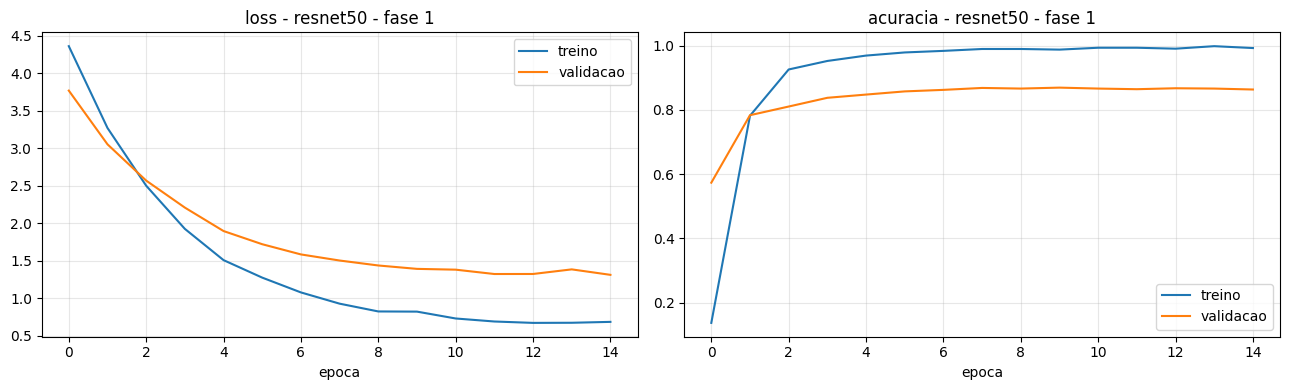


 teacher: VGG16 | dataset: flowers102
encoder vgg16 congelado.
  parametros treinaveis: 52,326


  epoca   1 | loss_tr=4.4879 acc_tr=0.037 | loss_vl=4.0313 acc_vl=0.274


  epoca   5 | loss_tr=2.5212 acc_tr=0.857 | loss_vl=2.5351 acc_vl=0.735


  epoca  10 | loss_tr=1.6891 acc_tr=0.929 | loss_vl=1.9580 acc_vl=0.799


  epoca  15 | loss_tr=1.5404 acc_tr=0.943 | loss_vl=1.8700 acc_vl=0.804
  melhor acc validacao: 0.8043
  acuracia TESTE: 0.7685
  classificador salvo em checkpoints/


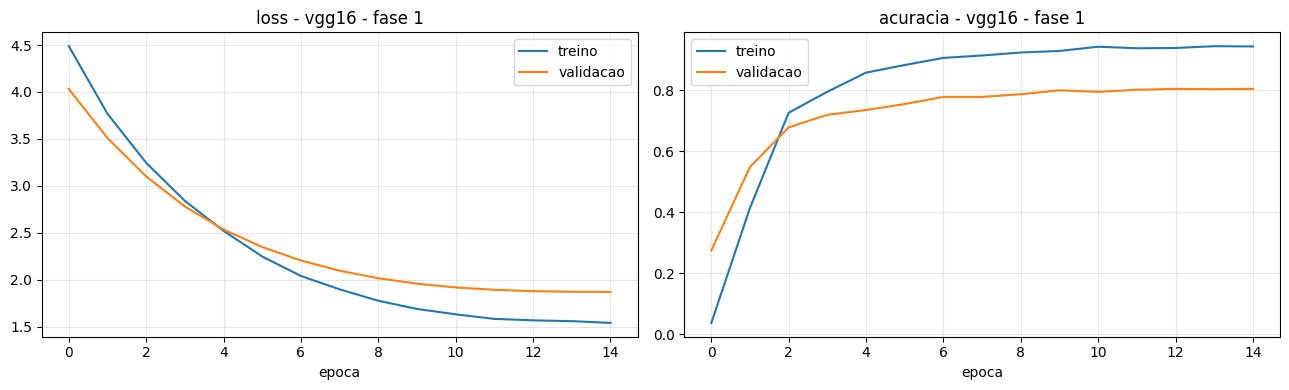


 teacher: CONVNEXT_SMALL | dataset: flowers102
encoder convnext_small congelado.
  parametros treinaveis: 79,974


  epoca   1 | loss_tr=4.2759 acc_tr=0.106 | loss_vl=3.0902 acc_vl=0.480


  epoca   5 | loss_tr=0.9935 acc_tr=0.902 | loss_vl=0.9572 acc_vl=0.866


  epoca  10 | loss_tr=0.4506 acc_tr=0.973 | loss_vl=0.6505 acc_vl=0.893


  epoca  15 | loss_tr=0.3713 acc_tr=0.976 | loss_vl=0.6122 acc_vl=0.901
  melhor acc validacao: 0.9008
  acuracia TESTE: 0.8645
  classificador salvo em checkpoints/


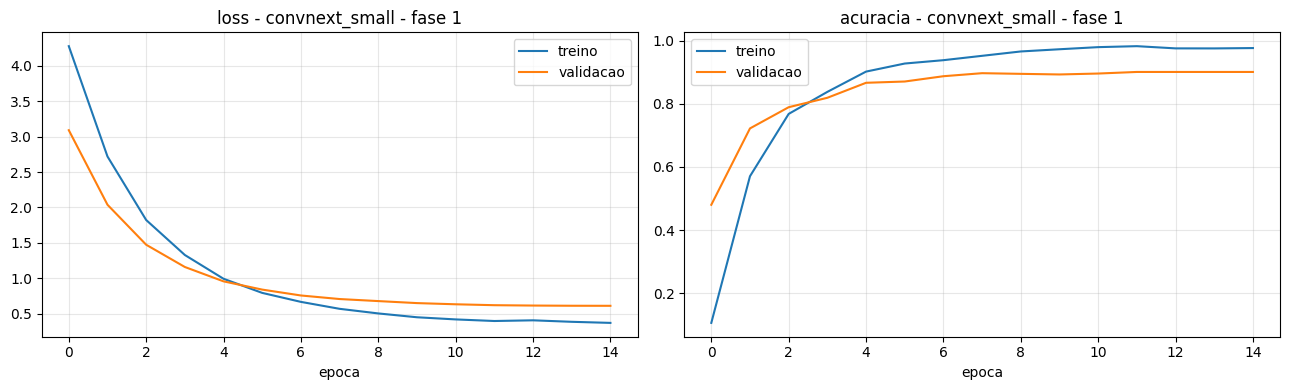

In [26]:

# ── fase 1: treinar classificador de cada teacher ──────────────────────────

DATASET_ESCOLHIDO = 'flowers102'  # troque por 'pets' para o segundo dataset
N_CLASSES         = DATASETS[DATASET_ESCOLHIDO]['n_classes']
EPOCHS_FASE1      = 15            # 15 epocas sao suficientes: o encoder ja e bom
LR_FASE1          = 1e-3

# dicionario para guardar resultados de todos os teachers
resultados_fase1 = {}

# ── loop pelos tres teachers ─────────────────────────────────────────────────
for nome_teacher in ['resnet50', 'vgg16', 'convnext_small']:
    print(f"\n{'='*60}")
    print(f" teacher: {nome_teacher.upper()} | dataset: {DATASET_ESCOLHIDO}")
    print(f"{'='*60}")

    # cria o teacher e congela o encoder (passo obrigatorio)
    teacher = TeacherWrapper(nome_teacher, n_classes=N_CLASSES).to(device)
    teacher.freeze_encoder()

    # apenas os parametros do classificador sao atualizados
    params_treinaveis = [p for p in teacher.parameters() if p.requires_grad]
    print(f"  parametros treinaveis: {sum(p.numel() for p in params_treinaveis):,}")

    optimizer = optim.Adam(params_treinaveis, lr=LR_FASE1, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FASE1)

    historico = trainer.treinar_fase1(
        model        = teacher,
        loader_train = DATASETS[DATASET_ESCOLHIDO]['train'],
        loader_val   = DATASETS[DATASET_ESCOLHIDO]['val'],
        optimizer    = optimizer,
        scheduler    = scheduler,
        n_epochs     = EPOCHS_FASE1,
        descricao    = nome_teacher,
    )

    # avalia no conjunto de teste
    acc_teste = trainer.avaliar_loader(teacher, DATASETS[DATASET_ESCOLHIDO]['test'])
    print(f"  acuracia TESTE: {acc_teste:.4f}")

    resultados_fase1[nome_teacher] = {
        'teacher_obj': teacher,
        'historico':   historico,
        'acc_teste':   acc_teste,
    }

    # salva o classificador (sera reutilizado exatamente na fase 3)
    os.makedirs("checkpoints", exist_ok=True)
    torch.save(teacher.classifier.state_dict(),
               f"checkpoints/classifier_{nome_teacher}_{DATASET_ESCOLHIDO}.pth")
    print(f"  classificador salvo em checkpoints/")
    plotar_curvas(historico, titulo=f"{nome_teacher} - fase 1")


In [27]:
# tabela de comparacao: Q1 - qual teacher transfere melhor?

print("\nQ1 - Comparacao de Teachers (Fase 1)\n")
linhas = []
for nome, dados in resultados_fase1.items():
    linhas.append({'teacher': nome, 'acc_teste': dados['acc_teste']})

df_q1 = pd.DataFrame(linhas).sort_values('acc_teste', ascending=False)
df_q1['params_M'] = df_q1['teacher'].map({'vgg16': 138, 'resnet50': 25, 'convnext_small': 50})
df_q1['gflops']   = df_q1['teacher'].map({'vgg16': 15.5, 'resnet50': 4.1, 'convnext_small': 8.7})
print(df_q1.to_string(index=False))
print()
print("-> observacao esperada: accuracy nao e proporcional ao tamanho do teacher")
print("-> capacidade de transferencia depende da qualidade das representacoes")



Q1 - Comparacao de Teachers (Fase 1)

       teacher  acc_teste  params_M  gflops
convnext_small   0.864475        50     8.7
      resnet50   0.835654        25     4.1
         vgg16   0.768459       138    15.5

-> observacao esperada: accuracy nao e proporcional ao tamanho do teacher
-> capacidade de transferencia depende da qualidade das representacoes


---
## Secao 4 - Arquitetura do Student

### Objetivo: muito menor, quase igual em precisao

O student deve ser consideravelmente mais leve que o teacher:
- Menos de 10% dos GFLOPs do teacher
- Menos de 20% dos parametros do teacher

### Duas partes do student

```
Imagem
  |
[ENCODER DO STUDENT]
(CNN leve que aprende features proprias)
  |
Features: [B, C_s, H_s, W_s]
  |
[PREDITOR DO STUDENT]
(mapeia features student -> espaco do teacher)
  |
Predicao: [B, C_teacher]
```

### Q2 - Tipos de preditor

| Tipo | Alvo | Preditor | Vantagem |
|------|------|----------|----------|
| **post-GAP** | vetor [B, C_t] | MLP (denso) | simples, dimensao baixa |
| **pre-GAP** | mapa [B, C_t, 7, 7] | Conv + pool | preserva localizacao espacial |

### Q3 - Tres variantes de encoder

| Variante | Descricao | Custo |
|----------|-----------|-------|
| PlainCNN | Conv-BN-ReLU empilhados | baseline |
| DepthwiseCNN | Convolucao depthwise-separavel (MobileNet) | ~8x menos params |
| MiniResNet | Conv + skip connections | melhor fluxo de gradiente |


In [28]:

# encoders do student definidos em kd_utils.py:
#   PlainCNNEncoder    - conv blocks empilhados (baseline)
#   DepthwiseCNNEncoder - depthwise-separavel, ~8x menos params (MobileNet-style)
#   MiniResNetEncoder  - conv blocks + skip connections (melhor fluxo de gradiente)
#
# conv_block e ResBlock tambem estao em kd_utils.py
# conv_block(dw=True) usa convolucao depthwise-separavel

# verificacao de shapes e parametros
print("shapes e parametros dos encoders do student:\n")
dummy = torch.randn(2, 3, 224, 224)
STUDENT_CHANNELS = (32, 64, 128, 256)

for nome, Encoder in [('PlainCNN', PlainCNNEncoder),
                       ('Depthwise', DepthwiseCNNEncoder),
                       ('MiniResNet', MiniResNetEncoder)]:
    enc = Encoder(STUDENT_CHANNELS)
    with torch.no_grad():
        out = enc(dummy)
    params = sum(p.numel() for p in enc.parameters()) / 1e6
    print(f"  {nome:12s} | saida: {str(out.shape):24s} | params: {params:.2f}M")


shapes e parametros dos encoders do student:

  PlainCNN     | saida: torch.Size([2, 256, 14, 14]) | params: 0.39M
  Depthwise    | saida: torch.Size([2, 256, 14, 14]) | params: 0.05M
  MiniResNet   | saida: torch.Size([2, 256, 14, 14]) | params: 1.94M


In [29]:

# preditores definidos em kd_utils.py:
#   PreditorPostGAP - mapeia features student -> vetor C_teacher (MLP)
#   PreditorPreGAP  - mapeia features student -> mapa espacial [B, C_t, 7, 7]
#   StudentModel    - encoder + preditor completo

# verificacao de shapes dos dois tipos de preditor (Q2)
print("shapes dos preditores:\n")
dummy_feat = torch.randn(2, 256, 14, 14)
for nome_t, dim_t in [('resnet50', 2048), ('vgg16', 512), ('convnext_small', 768)]:
    pred_post = PreditorPostGAP(256, dim_t)
    pred_pre  = PreditorPreGAP(256, dim_t)
    with torch.no_grad():
        out_post = pred_post(dummy_feat)
        out_pre  = pred_pre(dummy_feat)
    print(f"  teacher={nome_t:15s} | post-gap: {str(out_post.shape):16s} | pre-gap: {str(out_pre.shape)}")


shapes dos preditores:

  teacher=resnet50        | post-gap: torch.Size([2, 2048]) | pre-gap: torch.Size([2, 2048, 7, 7])
  teacher=vgg16           | post-gap: torch.Size([2, 512]) | pre-gap: torch.Size([2, 512, 7, 7])
  teacher=convnext_small  | post-gap: torch.Size([2, 768]) | pre-gap: torch.Size([2, 768, 7, 7])


---
## Secao 5 - Funcoes de Perda (Q4 e Q5)

### Q4 - Combinacao MSE + Cross-Entropy

A perda total combina dois objetivos:

$$L_{total} = \alpha \cdot L_{MSE} + (1 - \alpha) \cdot L_{CE}$$

- **$L_{MSE}$**: alinha features do student com features do teacher
- **$L_{CE}$**: mantém previsoes alinhadas com rotulos verdadeiros
- **$\alpha$**: hiperparametro para balancear os dois objetivos

| alpha | Significado |
|-------|-------------|
| 1.0 | so MSE (destilacao pura, sem rotulos) |
| 0.0 | so CE (ignora teacher) |
| 0.7 | ponto de partida recomendado |

### Q5 - Relational Knowledge Distillation (RKD)

Ao inves de alinhar **valores absolutos** de features, o RKD alinha as
**relacoes entre amostras** (distancias par-a-par):

> "Amostras similares no espaco do teacher devem ser similares no espaco do student"
> (Park et al., CVPR 2019)

Isso e **invariante a escala** das features e pode ser mais robusto quando
o student tem capacidade menor que o teacher (capacity mismatch).


In [30]:

# funcoes de perda definidas em kd_utils.py:
#   PerdaKD  - L = alpha * MSE + (1 - alpha) * CE (Q4)
#   PerdaRKD - alinha distancias par-a-par ao inves de valores absolutos (Q5)

# teste rapido das funcoes de perda
print("testando funcoes de perda:")
pred_s = torch.randn(8, 2048)
feat_t = torch.randn(8, 2048)
logits = torch.randn(8, 100)
labels = torch.randint(0, 100, (8,))

perda_kd  = PerdaKD(alpha=0.7)
perda_rkd = PerdaRKD()

l_total, l_mse, l_ce = perda_kd(pred_s, feat_t, logits, labels)
l_rkd = perda_rkd(pred_s, feat_t)

print(f"  perda kd  (alpha=0.7): total={l_total:.4f} | mse={l_mse:.4f} | ce={l_ce:.4f}")
print(f"  perda rkd:             {l_rkd:.4f}")


testando funcoes de perda:
  perda kd  (alpha=0.7): total=3.1696 | mse=2.0069 | ce=5.8825
  perda rkd:             0.0014


---
## Secao 6 - Fase 2: Treinar o Student por Destilacao

### Como funciona a Fase 2?

O teacher esta completamente congelado. O student aprende a imitar
as features do teacher atraves do gradiente da perda de destilacao.

```
Imagem -> [TEACHER ENCODER, congelado] -> features_teacher (alvo, sem gradiente)
Imagem -> [STUDENT ENCODER, treina]    -> features_student_raw
       -> [PREDITOR, treina]           -> pred_features
                                             |
                                  MSE(pred_features, features_teacher)
                                  + CE(classifier(pred_features), labels)
```

### Ponto critico: `torch.no_grad()` no teacher

Ao extrair features do teacher, NUNCA deixe gradientes fluirem pelo encoder.
Use sempre `with torch.no_grad():` para economizar memoria e tempo de computo.


In [31]:

# loops de destilacao definidos em kd_utils.py (Trainer):
#   trainer.treinar_fase2       - loop completo com registro de metricas
#   trainer.validar_student     - avalia student com classificador do teacher
#   trainer._treinar_batch_kd   - um passo de treino de destilacao
#
# Ponto critico: torch.no_grad() no teacher (nunca deixe gradientes fluirem pelo encoder)
# O teacher esta completamente congelado na Fase 2.

# trainer ja foi inicializado na secao 3 (celula acima do loop da fase 1)
print("trainer pronto para a fase 2.")


trainer pronto para a fase 2.


In [32]:

# experimento principal fase 2: responde Q1, Q2, Q3 e Q4

EPOCHS_FASE2  = 30      # aumente para 50 no experimento final
LR_FASE2      = 1e-3
DATASET_FASE2 = 'flowers102'

# configuracoes do experimento (teacher, encoder, modo_target, alpha)
CONFIGS_EXPERIMENTO = [
    # Q3: comparar tres encoders com mesmo teacher e alpha
    ('resnet50', PlainCNNEncoder,     'post_gap', 0.7),
    ('resnet50', DepthwiseCNNEncoder, 'post_gap', 0.7),
    ('resnet50', MiniResNetEncoder,   'post_gap', 0.7),
    # Q2: comparar pre-gap vs post-gap com mesmo encoder
    ('resnet50', PlainCNNEncoder,     'pre_gap',  0.7),
    # Q1: comparar outros teachers
    ('vgg16',          PlainCNNEncoder, 'post_gap', 0.7),
    ('convnext_small', PlainCNNEncoder, 'post_gap', 0.7),
    # Q4: ablacao de alpha (so MSE, so CE, combinacoes)
    ('resnet50', PlainCNNEncoder, 'post_gap', 1.0),
    ('resnet50', PlainCNNEncoder, 'post_gap', 0.5),
    ('resnet50', PlainCNNEncoder, 'post_gap', 0.0),
]

resultados_fase2 = []

for nome_teacher, EncoderCls, modo_target, alpha in CONFIGS_EXPERIMENTO:
    descricao = f"{nome_teacher[:3]}_{EncoderCls.__name__[:5]}_{modo_target[:3]}_a{alpha}"
    print(f"\n{'─'*62}")
    print(f" teacher={nome_teacher} | encoder={EncoderCls.__name__}")
    print(f" target={modo_target} | alpha={alpha}")
    print(f"{'─'*62}")

    # recupera teacher ja treinado na fase 1
    teacher = resultados_fase1[nome_teacher]['teacher_obj'].to(device)

    # constroi o student
    encoder  = EncoderCls(STUDENT_CHANNELS)
    dim_t    = teacher.feat_dim
    preditor = (PreditorPostGAP(encoder.out_dim, dim_t)
                if modo_target == 'post_gap'
                else PreditorPreGAP(encoder.out_dim, dim_t))
    student = StudentModel(encoder, preditor).to(device)

    # relatorio de eficiencia (Q3)
    params_s = sum(p.numel() for p in student.parameters()) / 1e6
    params_t = sum(p.numel() for p in teacher.parameters()) / 1e6
    print(f"  params student: {params_s:.2f}M | teacher: {params_t:.2f}M ({params_s/params_t*100:.1f}%)")

    # treina por destilacao via trainer.treinar_fase2 (kd_utils.py)
    perda_fn = PerdaKD(alpha=alpha)
    historico, melhor_acc = trainer.treinar_fase2(
        student      = student,
        teacher      = teacher,
        loader_train = DATASETS[DATASET_FASE2]['train'],
        loader_val   = DATASETS[DATASET_FASE2]['val'],
        perda_fn     = perda_fn,
        n_epochs     = EPOCHS_FASE2,
        lr           = LR_FASE2,
        modo_target  = modo_target,
        descricao    = descricao,
    )

    resultados_fase2.append({
        'descricao':   descricao,
        'teacher':     nome_teacher,
        'encoder':     EncoderCls.__name__,
        'modo_target': modo_target,
        'alpha':       alpha,
        'melhor_acc':  melhor_acc,
        'params_M':    params_s,
        'historico':   historico,
        'student_obj': student,
    })

    os.makedirs("checkpoints", exist_ok=True)
    torch.save(student.state_dict(), f"checkpoints/student_{descricao}.pth")



──────────────────────────────────────────────────────────────
 teacher=resnet50 | encoder=PlainCNNEncoder
 target=post_gap | alpha=0.7
──────────────────────────────────────────────────────────────
  params student: 1.57M | teacher: 23.72M (6.6%)


  ep.  1 | mse=0.0375 | acc_tr=0.010 | acc_vl=0.013


  ep.  5 | mse=0.0339 | acc_tr=0.101 | acc_vl=0.092


  ep. 10 | mse=0.0328 | acc_tr=0.169 | acc_vl=0.139


  ep. 15 | mse=0.0324 | acc_tr=0.233 | acc_vl=0.217


...

  ep. 10 | mse=0.0587 | acc_tr=0.014 | acc_vl=0.008


  ep. 15 | mse=0.0588 | acc_tr=0.011 | acc_vl=0.007


  ep. 20 | mse=0.0593 | acc_tr=0.008 | acc_vl=0.008


  ep. 25 | mse=0.0587 | acc_tr=0.010 | acc_vl=0.008


  ep. 30 | mse=0.0588 | acc_tr=0.011 | acc_vl=0.007
  melhor acc validacao: 0.0127


---
## Secao 7 - Q5: Comparacao com a Literatura (RKD)

### Por que RKD pode superar o MSE baseline?

O MSE forca o student a copiar os **valores absolutos** das features do teacher.
Isso pode ser dificil quando o student tem capacidade menor (capacity mismatch).

O RKD alinha as **relacoes entre amostras** ao inves de valores absolutos:
> "Amostras similares no espaco do teacher devem ser similares no espaco do student"

Essa abordagem e invariante a escala das features e captura a geometria
do espaco de representacao sem exigir alinhamento perfeito ponto-a-ponto.


In [33]:

# comparacao mse-baseline vs rkd (Q5)
# trainer.comparar_mse_vs_rkd encapsula o loop de comparacao (kd_utils.py)
#
# MSE forca o student a copiar os valores absolutos das features.
# RKD alinha as relacoes entre amostras, invariante a escala.
# Util quando o student tem capacidade menor (capacity mismatch).

# descomente para executar:
# teacher_q5     = resultados_fase1['resnet50']['teacher_obj'].to(device)
# resultados_q5  = trainer.comparar_mse_vs_rkd(
#     teacher      = teacher_q5,
#     datasets     = DATASETS,
#     teacher_nome = 'resnet50',
#     dataset_nome = 'flowers102',
#     n_epochs     = 20,
# )
# plotar_comparacao_mse_rkd(resultados_q5, 'resnet50', 'flowers102')


---
## Secao 8 - Fase 3: Avaliacao Final

### O teste definitivo

Na Fase 3, o **classificador da Fase 1** (congelado) e usado para avaliar
o student no conjunto de **teste**. Isso mede diretamente se o student
aprendeu a produzir features no mesmo espaco do teacher.

Se o student aprendeu bem as representacoes, o classificador do teacher
conseguira classificar as predicoes do student com alta acuracia, mesmo
nunca tendo visto as features do student durante o treinamento.


In [34]:

# avaliacao final na fase 3
# evaluator.avaliar_fase3 usa o classificador do teacher para avaliar o student
# o classificador nunca viu as features do student: transferencia real de conhecimento

print("Avaliacao Fase 3 - todos os experimentos\n")
print(f"{'descricao':45s} {'acc_val':>8s} {'acc_test':>9s} {'params_M':>9s}")
print("─" * 76)

for exp in resultados_fase2:
    teacher = resultados_fase1[exp['teacher']]['teacher_obj'].to(device)
    acc_test, acc_top5 = evaluator.avaliar_fase3(
        exp['student_obj'], teacher,
        DATASETS[DATASET_FASE2]['test'],
        exp['modo_target']
    )
    exp['acc_test'] = acc_test
    top5_str = f" (top5={acc_top5:.3f})" if acc_top5 else ""
    print(f"  {exp['descricao']:43s} {exp['melhor_acc']:>8.4f} {acc_test:>9.4f} {exp['params_M']:>9.2f}M{top5_str}")


Avaliacao Fase 3 - todos os experimentos

descricao                                      acc_val  acc_test  params_M
────────────────────────────────────────────────────────────────────────────
  res_Plain_pos_a0.7                            0.3119    0.2558      1.57M (top5=0.539)
  res_Depth_pos_a0.7                            0.2836    0.2377      1.23M (top5=0.521)
  res_MiniR_pos_a0.7                            0.2566    0.2013      3.12M (top5=0.494)
  res_Plain_pre_a0.7                            0.1574    0.1506      0.92M (top5=0.415)
  vgg_Plain_pos_a0.7                            0.2593    0.2106      0.78M (top5=0.495)
  con_Plain_pos_a0.7                            0.2077    0.1515      0.91M (top5=0.424)
  res_Plain_pos_a1.0                            0.3079    0.2542      1.57M (top5=0.547)
  res_Plain_pos_a0.5                            0.2994    0.2460      1.57M (top5=0.540)
  res_Plain_pos_a0.0                            0.0127    0.0152      1.57M (top5=0.047)


In [ ]:

# tabela final com respostas para cada questao de pesquisa
# df_resultados e construido aqui a partir de resultados_fase2
# (acc_test foi preenchido na celula de avaliacao da fase 3 acima)

df_resultados = pd.DataFrame([
    {
        'teacher':  r['teacher'],
        'encoder':  r['encoder'],
        'target':   r['modo_target'],
        'alpha':    r['alpha'],
        'acc_val':  r['melhor_acc'],
        'acc_test': r.get('acc_test', 0),
        'params_M': r['params_M'],
    }
    for r in resultados_fase2
])

# Q1
print("=" * 55)
print(" Q1 - QUAL TEACHER TRANSFERE MELHOR?")
print("=" * 55)
q1 = df_resultados[
    (df_resultados['encoder'] == 'PlainCNNEncoder') &
    (df_resultados['target']  == 'post_gap') &
    (df_resultados['alpha']   == 0.7)
][['teacher', 'acc_test']].sort_values('acc_test', ascending=False)
print(q1.to_string(index=False))

# Q2
print("\n" + "=" * 55)
print(" Q2 - PRE-GAP VS POST-GAP?")
print("=" * 55)
q2 = df_resultados[
    (df_resultados['teacher'] == 'resnet50') &
    (df_resultados['encoder'] == 'PlainCNNEncoder') &
    (df_resultados['alpha']   == 0.7)
][['target', 'acc_test']].sort_values('acc_test', ascending=False)
print(q2.to_string(index=False))

# Q3
print("\n" + "=" * 55)
print(" Q3 - MELHOR ARQUITETURA DO STUDENT?")
print("=" * 55)
q3 = df_resultados[
    (df_resultados['teacher'] == 'resnet50') &
    (df_resultados['target']  == 'post_gap') &
    (df_resultados['alpha']   == 0.7)
][['encoder', 'acc_test', 'params_M']].sort_values('acc_test', ascending=False)
print(q3.to_string(index=False))

# Q4
print("\n" + "=" * 55)
print(" Q4 - MELHOR FUNCAO DE PERDA?")
print("=" * 55)
q4 = df_resultados[
    (df_resultados['teacher'] == 'resnet50') &
    (df_resultados['encoder'] == 'PlainCNNEncoder') &
    (df_resultados['target']  == 'post_gap')
][['alpha', 'acc_test']].sort_values('alpha')
print(q4.to_string(index=False))


 Q1 - QUAL TEACHER TRANSFERE MELHOR?


NameError: name 'df_resultados' is not defined

In [ ]:

# graficos de analise final (plotar_graficos_analise em kd_utils.py)
# responde Q1, Q3 e Q4 visualmente
# df_resultados ja foi construido na celula de tabelas acima

plotar_graficos_analise(df_resultados)


---
## Secao 9 - Metricas de Eficiencia

Uma das metricas mais importantes e mostrar que o student e **muito mais eficiente**
que o teacher. Use `fvcore` para calcular GFLOPs automaticamente.


In [ ]:

# calculo de gflops e parametros
# evaluator.relatorio_eficiencia usa fvcore para contar operacoes (kd_utils.py)
# se fvcore nao estiver instalado, exibe apenas parametros

teacher_ref = resultados_fase1['resnet50']['teacher_obj']
evaluator.relatorio_eficiencia(teacher_ref, resultados_fase2)


---
## Secao 10 - Checklist Final e Proximos Passos

### O que voce ja implementou

- [x] Dois datasets (CIFAR-100 + STL-10)
- [x] Tres teachers (VGG-16, ResNet-50, ConvNeXt-Small)
- [x] Fase 1: treino do classificador com encoder congelado
- [x] Tres variantes de encoder do student (Plain, Depthwise, MiniResNet)
- [x] Dois preditores (post-GAP e pre-GAP)
- [x] Fase 2: loop de destilacao com MSE + CE
- [x] Ablacao de alpha (Q4)
- [x] Perda RKD para Q5
- [x] Fase 3: avaliacao com classificador fixo
- [x] Tabelas e graficos de analise

### Para completar o relatorio (responda cada questao)

| Questao | O que reportar |
|---------|----------------|
| Q1 | Tabela: teacher x acc_test nos 2 datasets |
| Q2 | Tabela: pre-GAP vs post-GAP; discuta trade-off espacial vs simplicidade |
| Q3 | Tabela: encoder x acc_test x GFLOPs x params |
| Q4 | Grafico: alpha x acc_test; identifique o alpha otimo |
| Q5 | Tabela: MSE vs RKD x acc_test; discuta quando RKD supera MSE |

### Melhorias para o experimento final

```python
# aumentar epocas (recomendado para resultados finais)
EPOCHS_FASE1 = 20
EPOCHS_FASE2 = 50

# repetir para o segundo dataset
for dataset_nome in ['cifar100', 'stl10']:
    for nome_teacher in ['resnet50', 'vgg16', 'convnext_small']:
        ...

# mixed precision para treinar mais rapido na GPU
from torch.cuda.amp import GradScaler, autocast
scaler = GradScaler()
with autocast():
    pred  = student(imgs)
    perda = perda_fn(...)
scaler.scale(perda).backward()
scaler.step(optimizer)
scaler.update()
```

### Referencias

1. Hinton et al. (2015) - Distilling the Knowledge in a Neural Network [arXiv:1503.02531]
2. Romero et al. (2015) - FitNets: Hints for Thin Deep Nets [ICLR 2015]
3. Zagoruyko & Komodakis (2017) - Paying More Attention to Attention [ICLR 2017]
4. Park et al. (2019) - Relational Knowledge Distillation [CVPR 2019]
5. Cooper et al. (2025) - Logit-Based Losses Limit Feature KD [OpenReview]
6. Goodfellow, Bengio & Courville (2016) - Deep Learning [MIT Press]


In [ ]:
### CRIAR CLASSES PARA ESSE NOTEBOOK
### rodar o claude com 4.7 e advanced thinking para criar um .py com as classes e funcoes principais
### (modelos, perdas, loop de treino) para deixar o notebook mais limpo e focado na analise dos resultados

In [ ]:
### CRIAR NOTEBOOKS SEPARADOS PARA CADA FASE para ir testando passo a passo

In [ ]:
### REVER O CODIGO PARA DEIXAR MAIS CLARO E ORGANIZADO (EX: SEPARAR FUNCOES DE TREINO, MODELOS, PERDAS, ETC)

In [ ]:
### rever o jeito que o codigo comenta as coisas e ajustar

In [ ]:
### entender que passos precisa de explicacoes mais matematicas e quais precisam de mais explicacoes intuitivas (ex: o que e rkd, porque usar mse + ce, etc)